### Imports

In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn import linear_model
import lightgbm as lgbm
import xgboost as xgb

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, KFold, GroupKFold

### Read files & submission file for template

In [49]:
X_train = pd.read_csv('../data/X_train.csv',index_col='ROW_ID')
X_test = pd.read_csv('../data/X_test.csv',index_col='ROW_ID')

y_train = pd.read_csv('../data/y_train.csv',index_col='ROW_ID')
sample_submission = pd.read_csv('../submissions/sample_submission.csv',index_col='ROW_ID')

### Features

In [50]:
print('Columns in X_train: \n',list(X_train.columns))

Columns in X_train: 
 ['TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9', 'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1', 'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18', 'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15', 'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12', 'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9', 'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6', 'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3', 'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP']


In [62]:
RET_features = [f'RET_{i}' for i in range(1,21)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,21)]
TURNOVER_features = ['MEDIAN_DAILY_TURNOVER']

In [75]:
# Impute missing values to X_train and X_test
cols_num_to_impute = [c for c in X_train.columns if c not in ['GROUP', 'TS', 'ALLOCATION']]
inputer_num = SimpleImputer(strategy='constant', fill_value=0)
X_train[cols_num_to_impute] = inputer_num.fit_transform(X_train[cols_num_to_impute])
X_test[cols_num_to_impute] = inputer_num.transform(X_test[cols_num_to_impute])

cols_cat_to_impute = ['GROUP']
inputer_cat = SimpleImputer(strategy='most_frequent')
X_train[cols_cat_to_impute] = inputer_cat.fit_transform(X_train[cols_cat_to_impute])
X_test[cols_cat_to_impute] = inputer_cat.transform(X_test[cols_cat_to_impute])

# Create new features based on the RET features (mean and std of the first n RET features, and their group means)
for i in [3,5,10,15,20]:
    X_train[ f'AVERAGE_PERF_{i}'] = X_train[RET_features[:i]].mean(1)
    X_train[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_train.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')
    
    X_test[ f'AVERAGE_PERF_{i}'] = X_test[RET_features[:i]].mean(1)
    X_test[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = X_test.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')

for i in [20]:
    X_train[ f'STD_PERF_{i}'] = X_train[RET_features[:i]].std(1)
    X_train[ f'ALLOCATIONS_STD_PERF_{i}'] = X_train.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')
    
    X_test[ f'STD_PERF_{i}'] = X_test[RET_features[:i]].std(1)
    X_test[ f'ALLOCATIONS_STD_PERF_{i}'] = X_test.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')

# Include the ALLOCATION feature as a categorical feature for the model (and hash it to integer to avoid issues with LightGBM)
hash_allocation = {v: i for i, v in enumerate(X_train['ALLOCATION'].unique())}

X_train['ALLOCATION'] = X_train['ALLOCATION'].map(hash_allocation)
X_test['ALLOCATION'] = X_test['ALLOCATION'].map(hash_allocation)

In [76]:
features = ['ALLOCATION'] + RET_features + SIGNED_VOLUME_features + TURNOVER_features + ['GROUP']
features = features + [ f'AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3,5,10,15,20]]
features = features + [ f'STD_PERF_{i}' for i in [20]]
features = features + [ f'ALLOCATIONS_STD_PERF_{i}' for i in [20]]

print('Features used for training:')
print(features)
print('Number of features :', len(features))

Features used for training:
['ALLOCATION', 'RET_1', 'RET_2', 'RET_3', 'RET_4', 'RET_5', 'RET_6', 'RET_7', 'RET_8', 'RET_9', 'RET_10', 'RET_11', 'RET_12', 'RET_13', 'RET_14', 'RET_15', 'RET_16', 'RET_17', 'RET_18', 'RET_19', 'RET_20', 'SIGNED_VOLUME_1', 'SIGNED_VOLUME_2', 'SIGNED_VOLUME_3', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_5', 'SIGNED_VOLUME_6', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_8', 'SIGNED_VOLUME_9', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_11', 'SIGNED_VOLUME_12', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_14', 'SIGNED_VOLUME_15', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_17', 'SIGNED_VOLUME_18', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_20', 'MEDIAN_DAILY_TURNOVER', 'GROUP', 'AVERAGE_PERF_3', 'AVERAGE_PERF_5', 'AVERAGE_PERF_10', 'AVERAGE_PERF_15', 'AVERAGE_PERF_20', 'ALLOCATIONS_AVERAGE_PERF_3', 'ALLOCATIONS_AVERAGE_PERF_5', 'ALLOCATIONS_AVERAGE_PERF_10', 'ALLOCATIONS_AVERAGE_PERF_15', 'ALLOCATIONS_AVERAGE_PERF_20', 'STD_PERF_20', 'ALLOCATIONS_STD_PERF_20']
Number of features : 55


### Fitting a lightgbm using cross validation

In [77]:
features_lgbm = features

In [123]:
# A quite large number of trees with low depth to prevent overfits
lgbm_params = {
                "objective": "mse","metric": "mse","num_threads": 100,"seed": 42,"verbosity": -1,'learning_rate': 1e-2,'max_depth': 3,}
NUM_BOOST_ROUND = 500   

n_splits = 8
scores_lgbm = []
models_lgbm = []

gkf = GroupKFold(n_splits=n_splits)

for i, (train_idx, test_idx) in enumerate(gkf.split(X_train[features_lgbm], y_train['target'], groups=X_train['TS'])):
    X_local_train = X_train.iloc[train_idx][features_lgbm]
    y_local_train = y_train.iloc[train_idx]['target']
    
    X_local_test = X_train.iloc[test_idx][features_lgbm]
    y_local_test = y_train.iloc[test_idx]['target']

    train_data = lgbm.Dataset(X_local_train, label=y_local_train.values, categorical_feature=['GROUP','ALLOCATION']) 
    
    model_lgbm = lgbm.train(lgbm_params, train_data,num_boost_round=NUM_BOOST_ROUND) 
    
    y_local_pred = model_lgbm.predict(X_local_test.values, num_threads = lgbm_params['num_threads'])
    
    models_lgbm.append(model_lgbm)
    score = accuracy_score((y_local_test>0).astype(int),
                (y_local_pred>-(1e-5)).astype(int))
    scores_lgbm.append(score)
    print(f"Fold {i+1} - Accuracy: {score* 100:.2f}%")

mean = np.mean(scores_lgbm)*100
std = np.std(scores_lgbm)*100

u = (mean + std)
l = (mean - std)

print(f'Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})')


Fold 1 - Accuracy: 51.96%
Fold 2 - Accuracy: 52.35%
Fold 3 - Accuracy: 52.30%


KeyboardInterrupt: 

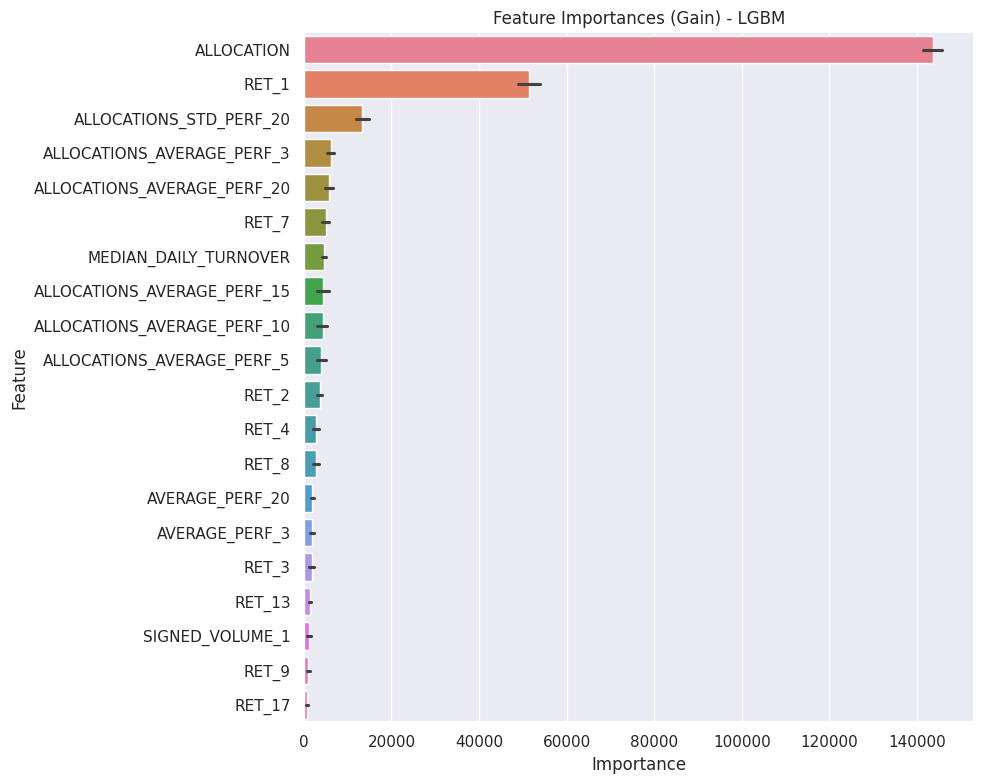

In [119]:
feature_importances = pd.DataFrame([model_lgbm.feature_importance(importance_type='gain') for model_lgbm in models_lgbm], columns=features_lgbm)

feature_importances = feature_importances.loc[:,feature_importances.mean(0).sort_values(ascending=False).index[:20]]

plt.figure(figsize=(10, 8))

sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index)
plt.title('Feature Importances (Gain) - LGBM')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

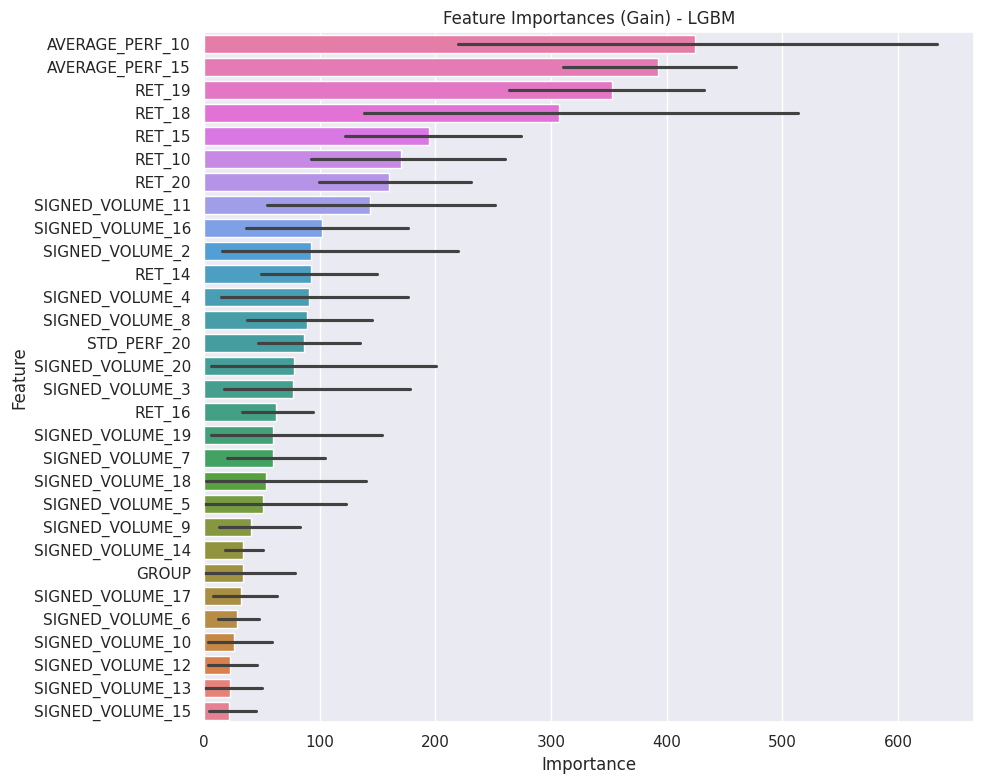

In [120]:
feature_importances = pd.DataFrame([model_lgbm.feature_importance(importance_type='gain') for model_lgbm in models_lgbm], columns=features_lgbm)

feature_importances = feature_importances.loc[:,feature_importances.mean(0).sort_values(ascending=True).index[:30]]

plt.figure(figsize=(10, 8))

sns.barplot(data=feature_importances, orient='h', order=feature_importances.mean().sort_values(ascending=False).index)
plt.title('Feature Importances (Gain) - LGBM')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [121]:
train_data = lgbm.Dataset(X_train[features_lgbm], label=y_train) 

model_lgbm = lgbm.train(lgbm_params, train_data,num_boost_round=NUM_BOOST_ROUND) 
preds_lgbm = model_lgbm.predict(X_test[features_lgbm])
preds_lgbm = pd.DataFrame(preds_lgbm, index=sample_submission.index,columns=['target']) 

In [122]:
(preds_lgbm>-(1e-5)).astype(int).to_csv('../submissions/preds_lgbm_alloc_mae_offset.csv')
print('LGBM predictions saved to ../submissions/preds_lgbm_alloc_mae_offset.csv')

LGBM predictions saved to ../submissions/preds_lgbm_alloc_mae_offset.csv


### Fitting a XGBoost using cross validation

In [102]:
features_xgb = features

In [106]:

# A quite large number of trees with low depth to prevent overfits
xgb_params = {
                "objective": "reg:squarederror",
                "eval_metric": "rmse",
                "alpha": 1.0,
                "nthread": 50,
                "seed": 42,
                "verbosity": 0,
                'learning_rate': 1e-2,
                'max_depth': 3,
}

NUM_BOOST_ROUND = 500

n_splits = 8
scores_xgb = []
models_xgb = []

gkf = GroupKFold(n_splits=n_splits)

for i, (train_idx, test_idx) in enumerate(gkf.split(X_train[features_xgb], y_train['target'], groups=X_train['TS'])):
    X_local_train = X_train.iloc[train_idx][features_xgb]
    y_local_train = y_train.iloc[train_idx]['target']
    
    X_local_test = X_train.iloc[test_idx][features_xgb]
    y_local_test = y_train.iloc[test_idx]['target']
    
    train_data = xgb.DMatrix(X_local_train.fillna(0), label=y_local_train.values)
    model_xgb = xgb.train(xgb_params, train_data,num_boost_round=NUM_BOOST_ROUND) 
    
    test_data = xgb.DMatrix(X_local_test.fillna(0))
    y_local_pred = model_xgb.predict(test_data) 
    
    models_xgb.append(model_xgb)
    score = accuracy_score((y_local_test>0).astype(int),
                (y_local_pred>0).astype(int))
    scores_xgb.append(score)
    print(f"Fold {i+1} - Accuracy: {score* 100:.2f}%")

mean = np.mean(scores_xgb)*100
std = np.std(scores_xgb)*100

u = (mean + std)
l = (mean - std)

print(f'Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})')


Fold 1 - Accuracy: 51.69%
Fold 2 - Accuracy: 52.35%
Fold 3 - Accuracy: 52.10%
Fold 4 - Accuracy: 51.99%
Fold 5 - Accuracy: 53.38%
Fold 6 - Accuracy: 51.93%
Fold 7 - Accuracy: 52.27%
Fold 8 - Accuracy: 51.69%
Accuracy: 52.17% [51.66 ; 52.68] (+- 0.51)


In [ ]:
train_data = xgb.DMatrix(X_train[features_xgb].fillna(0), label=y_train.values) 
test_data = xgb.DMatrix(X_test[features_xgb].fillna(0))

model_xgb = xgb.train(xgb_params, train_data,num_boost_round=NUM_BOOST_ROUND)
preds_xgb = model_xgb.predict(test_data)
preds_xgb = pd.DataFrame(preds_xgb, index=sample_submission.index,columns=['target'])

In [ ]:
(preds_xgb>0).astype(int).to_csv('../submissions/preds_xgb_groups.csv')
print('XGB predictions saved to ../submissions/preds_xgb_groups.csv')